In [2]:
import numpy as np
import matplotlib.pyplot as plt

from edibles.utils.local_continuum_spline import *

from edibles.utils.final_voigt_profile import *
from edibles.utils.final_fitter import *

from edibles.utils.edibles_oracle import EdiblesOracle
from edibles.utils.edibles_spectrum import EdiblesSpectrum 
## in the earlier codes these 2 lines were not needed as this ipynb file used to sit inside the edibles/utils/ folder.


from IPython.display import display, Math

from scipy.interpolate import CubicSpline


from edibles.utils3.model import *

In [3]:
sightline = "HD 161056"
pythia = EdiblesOracle()
List_1 = pythia.getFilteredObsList(object=[sightline], MergedOnly=False, Wave=4232.0)
test_1 = List_1.values.tolist()
List_2 = pythia.getFilteredObsList(object=[sightline], MergedOnly=True, Wave=4232.0)
test_2 = List_2.values.tolist()
test = set(test_1) - set(test_2)
test = list(test)


/Users/ayansahoo/Desktop/MITACS_2024_Canada/edibles/DR4
***Common Objects***
['HD 161056']
**Filtered File List**
5401    /HD161056/BLUE_437/HD161056_w437_blue_20170508...
5424    /HD161056/BLUE_437/HD161056_w437_n6_20170508_B...
5429    /HD161056/BLUE_437/HD161056_w437_blue_20170508...
Name: Filename, dtype: object
3
***Common Objects***
['HD 161056']
**Filtered File List**
5424    /HD161056/BLUE_437/HD161056_w437_n6_20170508_B...
Name: Filename, dtype: object
1


In [4]:
for i in test:
    if i.endswith("O15.fits"):
        print(i)

/HD161056/BLUE_437/HD161056_w437_blue_20170508_O15.fits


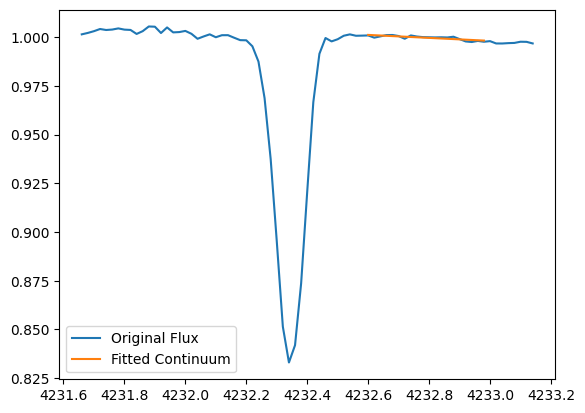

Standard deviation of flux: 0.0006812275906287707


In [5]:
filename = "/HD161056/BLUE_437/HD161056_w437_blue_20170508_O15.fits" # mention the file which needs fitting
wrange = [4231.65, 4233.15]
sp = EdiblesSpectrum(filename)
sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
wave = sp.bary_wave
flux = sp.bary_flux

# Filter the spectrum within the specified wavelength range
idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
wave = wave[idx]
flux = flux[idx]
# Normalize the flux
flux = flux / np.median(flux)
continuum, std_dev = local_continuum(wave, flux, positions=[4232.8], windows=[0.4], spline_order=1, silent=False)

## this local_continuum function is different from what is in the edibles repo. it was created by us and is in a email sent by Debayan 

print("Standard deviation of flux:", std_dev)

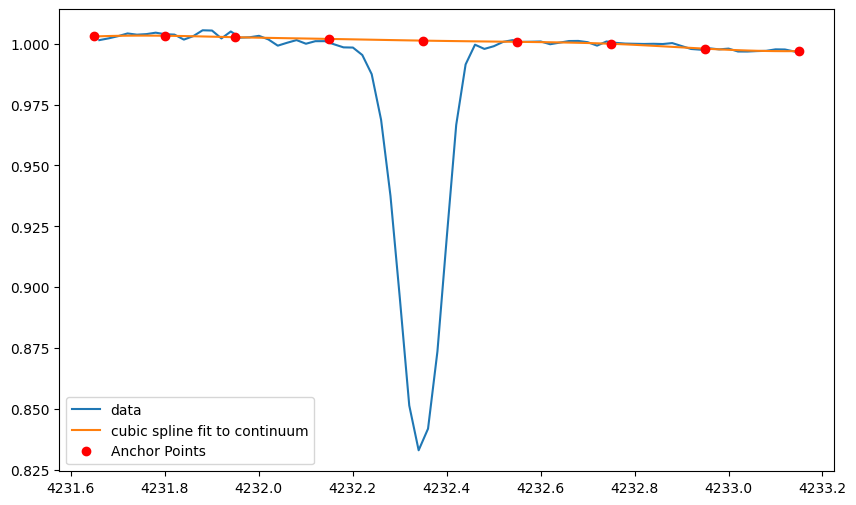

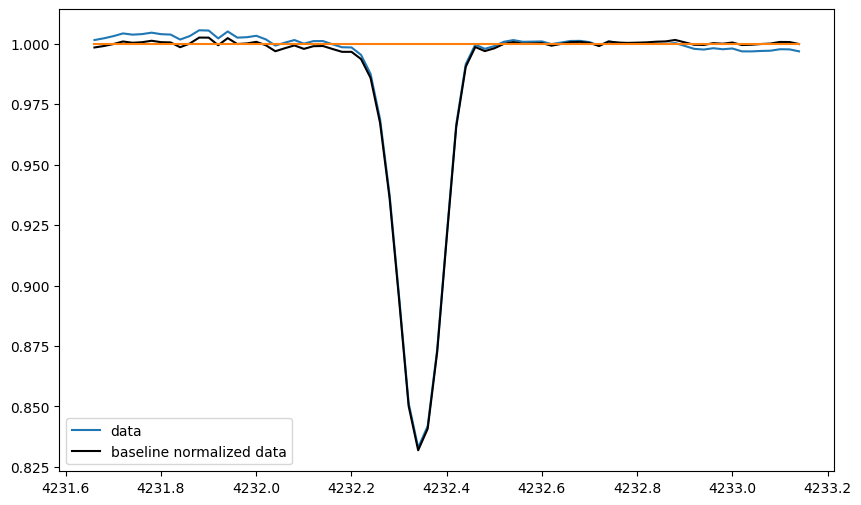

In [6]:
## next try to fit continuum using cubic splines

anchor_points_wave = np.array([4231.65, 4231.8, 4231.95, 4232.15, 4232.35, 4232.55, 4232.75, 4232.95, 4233.15])
anchor_points_flux = np.array([1.003, 1.0033, 1.0027, 1.002, 1.0013, 1.0008, 1.00, 0.998, 0.997])

# anchor_points_wave = np.array([4231, 4231.25, 4231.5, 4231.75, 4232, 4232.12, 4232.29, 4232.72, 4232.85, 4233])
# anchor_points_flux = np.interp(anchor_points_wave, wave, flux)

# Fit cubic splines to the anchor points
cs = CubicSpline(anchor_points_wave, anchor_points_flux) # so the cubic spline routine is not really taking all the points into account. only anchors

# Generate the continuum model
continuum = cs(wave)

plt.figure(figsize=(10, 6))
plt.plot(wave, flux, label='data')
plt.plot(wave, continuum, label='cubic spline fit to continuum')
plt.plot(anchor_points_wave, anchor_points_flux, 'ro', label='Anchor Points')
plt.legend()
plt.show()

H = np.ones(wave.shape)
plt.figure(figsize=(10, 6))
plt.plot(wave, flux, label='data')
plt.plot(wave, flux / continuum, color='k', label='baseline normalized data')
plt.plot(wave, H)
plt.legend()
plt.show()

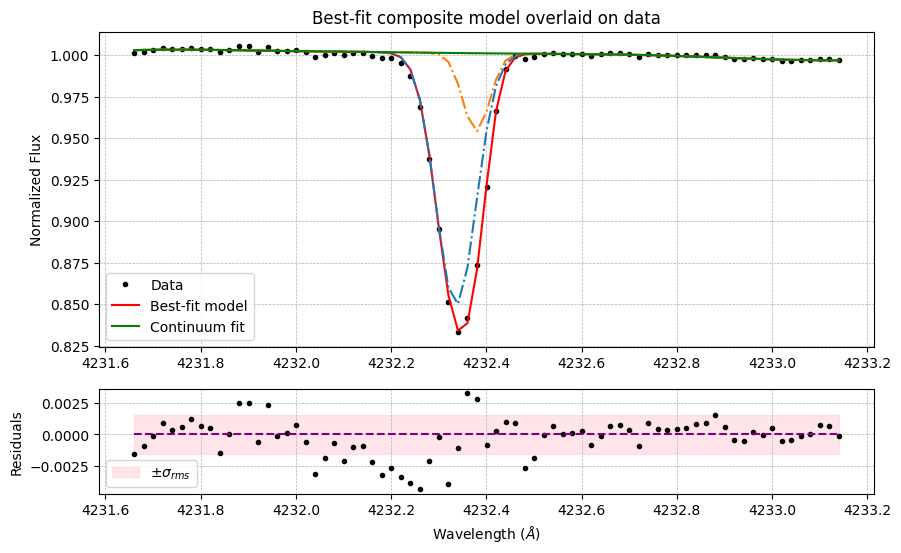

number of parameters: 6
Chi-squared: 391.12855455002517
Reduced Chi-squared: 5.668529776087321
RMS error after fit: 0.0015556839064707992
std_dev from continuum using line-free regions: 0.0006812275906287707
Log-likelihood: 282.3864
AIC:  -552.7727815219341
BIC:  -538.8678528407163


In [8]:
# Known params
lambda0 = np.array([4232.548, 4232.548])
wavegrid = wave
f = np.array([0.005450, 0.005450])
gamma = np.array([1e8, 1e8])


# Best-fit params
b = np.array([3.66, 2.13])  # in km/s
v_rad = np.array([-15, -12]) # in km/s
N = np.array([10**(13.2908), 10**(12.5940)])  # in cm^-2





model_fit = mother_function(wavegrid, lambda0=lambda0, f=f, gamma=gamma, b=b, 
                    N=N, v_rad=v_rad, v_resolution=3.0)

model_comp_0 = mother_function(wavegrid, lambda0=np.array([lambda0[0]]), f=np.array([f[0]]), gamma=np.array([gamma[0]]), b=np.array([b[0]]), 
                    N=np.array([N[0]]), v_rad=np.array([v_rad[0]]), v_resolution=3.0)
model_comp_1 = mother_function(wavegrid, lambda0=np.array([lambda0[1]]), f=np.array([f[1]]), gamma=np.array([gamma[1]]), b=np.array([b[1]]), 
                    N=np.array([N[1]]), v_rad=np.array([v_rad[1]]), v_resolution=3.0)

rms_error = np.sqrt((np.sum((flux - (continuum * model_fit))**2))/len(flux))






# Create a figure with the overall size (10, 8)
fig = plt.figure(figsize=(10, 6))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# Add the first subplot (upper image), which will take up 6/8 of the height
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title('Best-fit composite model overlaid on data')
ax1.plot(wave, flux, 'k.', label='Data')  
ax1.plot(wave, continuum * model_fit, 'r-', label='Best-fit model')
ax1.plot(wave, continuum * model_comp_0, '-.')
ax1.plot(wave, continuum * model_comp_1, '-.')
ax1.plot(wave, continuum, 'green', label='Continuum fit')
ax1.set_ylabel('Normalized Flux')
ax1.grid('on', which='both', linestyle='--', linewidth=0.5)
ax1.legend()

# Add the second subplot (lower image), which will take up 2/8 of the height
ax2 = fig.add_subplot(grid[1, 0])
# ax2.set_title('Residuals after fitting')
ax2.plot(wave, flux - (continuum * model_fit), 'k.')  
ax2.hlines(0, wave.min(), wave.max(), colors='purple', linestyles='dashed')
# ax2.hlines(rms_error, wave.min(), wave.max(), colors='red', linestyles='dashed')
# ax2.hlines(-rms_error, wave.min(), wave.max(), colors='red', linestyles='dashed')
ax2.set_ylabel('Residuals')
ax2.set_xlabel('Wavelength ($\AA$)')
ax2.grid('on', which='both', linestyle='--', linewidth=0.5)
ax2.fill_between(wave, -rms_error, rms_error, color='pink', alpha=0.4, label='$\pm \sigma_{rms}$')
ax2.legend()
# Show the plot
plt.show()

num_params=6

chi_squared = np.sum(((flux - (continuum * model_fit)) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(flux) - num_params)}")  
print(f"RMS error after fit: {rms_error}")
print(f"std_dev from continuum using line-free regions: {std_dev}")

# Calculate log-likelihood
num_data_points = len(flux)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


# should i convert x axis to radial velocity ?

# a more convenient way to give the parameters ?

In [167]:
import numpy as np
import matplotlib.pyplot as plt

from edibles.utils.local_continuum_spline import *

from edibles.utils.final_voigt_profile import *
from edibles.utils.final_fitter import *

from edibles.utils.edibles_oracle import EdiblesOracle
from edibles.utils.edibles_spectrum import EdiblesSpectrum 
## in the earlier codes these 2 lines were not needed as this ipynb file used to sit inside the edibles/utils/ folder.


from IPython.display import display, Math

from scipy.interpolate import CubicSpline


from edibles.utils3.model import *

In [245]:
'''
Sightline chooser
'''

sightline = "HD 145502"
pythia = EdiblesOracle()
List_1 = pythia.getFilteredObsList(object=[sightline], MergedOnly=False, Wave=4232.0)
test_1 = List_1.values.tolist()
List_2 = pythia.getFilteredObsList(object=[sightline], MergedOnly=True, Wave=4232.0)
test_2 = List_2.values.tolist()
test = set(test_1) - set(test_2)
test = list(test)


for i in test:
    if i.endswith("O15.fits"):
        print(i)

/Users/ayansahoo/Desktop/MITACS_2024_Canada/edibles/DR4
***Common Objects***
['HD 145502']
**Filtered File List**
2751    /HD145502/BLUE_437/HD145502_w437_n25_20140919_...
2762    /HD145502/BLUE_437/HD145502_w437_blue_20140919...
2771    /HD145502/BLUE_437/HD145502_w437_blue_20140919...
Name: Filename, dtype: object
3
***Common Objects***
['HD 145502']
**Filtered File List**
2751    /HD145502/BLUE_437/HD145502_w437_n25_20140919_...
Name: Filename, dtype: object
1
/HD145502/BLUE_437/HD145502_w437_blue_20140919_O15.fits


In [294]:
'''
File chooser
'''

filename = "/HD145502/BLUE_437/HD145502_w437_blue_20140919_O15.fits" # mention the file which needs fitting
parts = filename.split('/')
hd_number = parts[1]  # This gives "HD170740"
filename_only = parts[-1].split('.')[0]  # "HD170740_w437_blue_20140915_O15"
name_parts = filename_only.split('_')
date = name_parts[3]  # This gives "20140915"
print(f"HD Number: {hd_number}")
print(f"Date: {date} (YYYYMMDD)")
ID = hd_number + '-' + date #+ '(YYYYMMDD)'
print(ID)


# Continuum fitting using cubic splines
anchor_points_wave = np.array([4231.65, 4231.75, 4232, 4232.25, 4232.4, 4232.5, 4232.75, 4233, 4233.15])
anchor_points_flux = np.array([1.003, 1.0025, 1.0015, 1.000, 1.0005, 1.001, 1.00, 0.997, 0.998])

wrange = [anchor_points_wave[0], anchor_points_wave[-1]]
sp = EdiblesSpectrum(filename)
sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
wave = sp.bary_wave
flux = sp.bary_flux

# Filter the spectrum within the specified wavelength range
idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
wave = wave[idx]
flux = flux[idx]
# Normalize the flux
flux = flux / np.median(flux)

cs = CubicSpline(anchor_points_wave, anchor_points_flux) 
continuum_anchor_spline = cs(wave)
# continuum = cs(wave)


HD Number: HD145502
Date: 20140919 (YYYYMMDD)
HD145502-20140919


In [407]:

## additional continuum normalizatio using a linear fit through line-free regions
from astropy.modeling import models, fitting
wl = wave
f = flux / continuum_anchor_spline  # normalize by the existing continuum first

# Step 2: Define line-free continuum regions (in wavelength units)
# Adjust these based on your real data's absorption positions
left_region = (wl > 4231.65) & (wl < 4232)  # Left side, line-free
right_region = (wl > 4232.6) & (wl < 4233.15)  # Right side, line-free

# Mask for fitting the continuum (only line-free regions)
cont_mask = left_region | right_region

# Step 3: Fit a linear model to the continuum points
lin_model = models.Linear1D()
fitter = fitting.LinearLSQFitter()
continuum_fit = fitter(lin_model, wl[cont_mask], f[cont_mask])

# Evaluate the fitted line over the full region
continuum_lin = continuum_fit(wl)

continuum = continuum_anchor_spline * continuum_lin



# from astropy.modeling import models, fitting

# # Assume these are already defined:
# wl = wave
# f = flux / continuum_anchor_spline  # normalize by the existing continuum first

# # Step 2: Define line-free continuum regions (your specific regions)
# left_region  = (wl > 4231.65) & (wl < 4232.0)
# right_region = (wl > 4232.6)  & (wl < 4233.15)

# # Mask combining both line-free regions
# cont_mask = left_region | right_region

# # Step 3: Map wavelength to the [-1, 1] domain required by Chebyshev1D
# # This ensures numerical stability
# x_min = wl[cont_mask].min()
# x_max = wl[cont_mask].max()
# x_norm_full = 2 * (wl - x_min) / (x_max - x_min) - 1          # full array
# x_norm_mask = 2 * (wl[cont_mask] - x_min) / (x_max - x_min) - 1  # masked points

# # Step 4: Fit a 3rd-order Chebyshev polynomial to the coarsely normalized flux
# cheb_model = models.Chebyshev1D(degree=1, domain=[-1, 1])
# fitter = fitting.LinearLSQFitter()
# continuum_cheb_local = fitter(cheb_model, x_norm_mask, f[cont_mask])

# # Evaluate the local Chebyshev correction over the full wavelength range
# local_cheb_correction = continuum_cheb_local(x_norm_full)

# # Step 5: Combine the coarse spline with the local Chebyshev refinement
# continuum = continuum_anchor_spline * local_cheb_correction

# # Step 6: Final normalized flux
# final_normalized_flux = flux / final_continuum

# # Optional: quick check plot
# import matplotlib.pyplot as plt
# plt.figure(figsize=(10,5))
# plt.plot(wl, flux, label='Original flux', alpha=0.6)
# plt.plot(wl, continuum_anchor_spline, '--', label='Anchor spline')
# plt.plot(wl, final_continuum, 'r-', label='Final continuum (spline × local Cheb3)')
# plt.plot(wl, final_normalized_flux, 'g-', linewidth=2, label='Final normalized flux')
# plt.axvspan(4231.65, 4232.0, color='lightblue', alpha=0.3)
# plt.axvspan(4232.6, 4233.15, color='lightblue', alpha=0.3)
# plt.xlim(4231, 4234)
# plt.legend()
# plt.show()



In [408]:
'''
Inputs for best-fit model
'''

# Best-fit values
v_rad_1st = [0, 0]        # 13CH+ (only one component)
v_rad_2nd = [-17.3, -11.3]    # 12CH+

b_1st = [1, 1]             # 13CH+
b_2nd = [2.78, 2.88]          # 12CH+

lnN_1st = [0, 0]        # 13CH+    write 0 if u dont want to include this component
lnN_2nd = [12.1343, 12.6889]  # 12CH+


std_dev = 0.001   # Assuming a standard deviation for the error
num_params = 6  # Number of parameters in the model (adjust as necessary)

Exponents of N for 13CH+ clouds: []
Exponents of N for 12CH+ clouds: [12, 12]
13CH+ cloud parameters (N, b, v_rad): []
12CH+ cloud parameters (N, b, v_rad): ['(N:1.4$\\times 10^{12}$)(b:2.8)($v_{rad}$:-17.3)', '(N:4.9$\\times 10^{12}$)(b:2.9)($v_{rad}$:-11.3)']


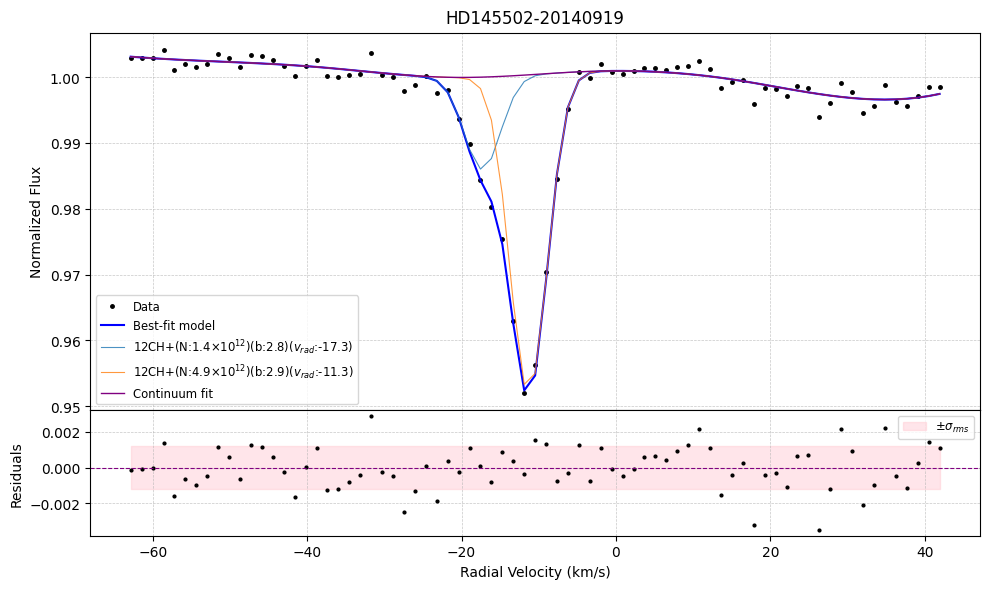

number of parameters: 6
Chi-squared: 107.99203721539959
Reduced Chi-squared: 1.5651019886289796
RMS error after fit: 0.0011999557614923398
std_dev from continuum using line-free regions: 0.001
Log-likelihood: 395.1652
AIC:  -778.3304746512201
BIC:  -764.4255459700023


In [409]:
# Known params
lambda_1st = [4232.288] # 13CH+
lambda_2nd = [4232.548] # 12CH+
f_1st = [0.005450] # 13CH+
f_2nd = [0.005450]# 12CH+
gamma_1st = [1e8] # 13CH+
gamma_2nd = [1e8] # 12CH+
v_resolution = 3  

# Converting lnN to N
N_1st = []
for n in range(len(lnN_1st)):
    if lnN_1st[n]==0:
        N_1st.append(0)
    else:
        N_1st.append(10**(lnN_1st[n]))
        

# if lnN_1st != [0, 0]:
#     N_1st = [10**i for i in lnN_1st]
# else:    
#     N_1st = [0, 0] 

N_2nd = [10**i for i in lnN_2nd]

expo_13CHp = [int(np.floor(np.log10(num))) for num in N_1st if num != 0] # is for typesetting the exponent value for each cloud
expo_12CHp = [int(np.floor(np.log10(num))) for num in N_2nd if num != 0]

print("Exponents of N for 13CH+ clouds:", expo_13CHp)
print("Exponents of N for 12CH+ clouds:", expo_12CHp)



# Separating out singular cloud components
num_clouds_1st = len(v_rad_1st) # 13CH+
num_clouds_2nd = len(v_rad_2nd) # 12CH+

clouds_13CHp = []
clouds_12CHp = []

params_13CHp = []
params_12CHp = []

for i in range(num_clouds_1st):
    if N_1st[i] != 0:
        abs_line_cloud = master_function(
            wave,
            lambda_1st=lambda_1st,
            f_1st=f_1st,
            gamma_1st=gamma_1st,
            N_1st=N_1st[i],
            b_1st=b_1st[i],
            v_rad_1st=v_rad_1st[i],
            v_resolution=v_resolution
        )
        clouds_13CHp.append(abs_line_cloud)
        params_13CHp.append('(N:'+f'{N_1st[i]/(10**expo_13CHp[i]):.1f}'+f'$\\times 10^{{{expo_13CHp[i]}}}$'+')(b:'+f'{b_1st[i]:.1f}'+')($v_{rad}$:'+f'{v_rad_1st[i]}'+')')
        
for i in range(num_clouds_2nd):
    if N_2nd[i] != 0:
        abs_line_cloud = master_function(
            wave,
            lambda_2nd=lambda_2nd,
            f_2nd=f_2nd,
            gamma_2nd=gamma_2nd,
            N_2nd=N_2nd[i],
            b_2nd=b_2nd[i],
            v_rad_2nd=v_rad_2nd[i],
            v_resolution=v_resolution
        )
        clouds_12CHp.append(abs_line_cloud)
        params_12CHp.append('(N:'+f'{N_2nd[i]/(10**expo_12CHp[i]):.1f}'+f'$\\times 10^{{{expo_12CHp[i]}}}$'+')(b:'+f'{b_2nd[i]:.1f}'+')($v_{rad}$:'+f'{v_rad_2nd[i]}'+')')
        
print("13CH+ cloud parameters (N, b, v_rad):", params_13CHp)
print("12CH+ cloud parameters (N, b, v_rad):", params_12CHp)

AbsorptionLine = master_function(
    wave,
    lambda_1st=lambda_1st,
    lambda_2nd=lambda_2nd,
    N_1st=N_1st,
    N_2nd=N_2nd,
    f_1st=f_1st,
    f_2nd=f_2nd,
    gamma_1st=gamma_1st,
    gamma_2nd=gamma_2nd,
    b_1st= b_1st,
    b_2nd= b_2nd,
    v_rad_1st = v_rad_1st,
    v_rad_2nd =v_rad_2nd,
    v_resolution=v_resolution
)

rms_error = np.sqrt((np.sum((flux - (continuum * AbsorptionLine))**2))/len(flux))


# Converting wavelength to raial velocity space
ref_wave = 4232.548  # reference wavelength for 12CH+
c = 299792.458  # speed of light in km/s
vel_axis = c * (wave - ref_wave) / ref_wave



# Create a figure with the overall size (10, 6)
fig = plt.figure(figsize=(10, 6))

# Create a GridSpec with 2 rows and 1 column, with different height ratios
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2], hspace=0)

# Add the first subplot (upper image)
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title(ID, pad=7)
ax1.plot(vel_axis, flux, 'k.', label='Data', markersize=5, alpha=1)  
ax1.plot(vel_axis, continuum * AbsorptionLine, 'b-', label='Best-fit model', linewidth=1.5)

# Plot cloud components
for j in range(len(clouds_13CHp)):
    ax1.plot(vel_axis, continuum * clouds_13CHp[j], '-', alpha=0.8, linewidth=0.8, label='13CH+'+params_13CHp[j])
for k in range(len(clouds_12CHp)):
    ax1.plot(vel_axis, continuum * clouds_12CHp[k], '-', alpha=0.8, linewidth=0.8, label='12CH+'+params_12CHp[k])

ax1.plot(vel_axis, continuum, 'purple', linewidth=1, label='Continuum fit')
ax1.set_ylabel('Normalized Flux')
ax1.grid('on', which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax1.legend(loc='best', fontsize='small')

# Remove x-axis tick labels from top plot (but keep the ticks)
ax1.tick_params(axis='x', which='both', labelbottom=False)

# Add the second subplot (lower image)
ax2 = fig.add_subplot(grid[1, 0])

# Plot residuals
residuals = flux - (continuum * AbsorptionLine)
ax2.plot(vel_axis, residuals, 'k.', markersize=4, alpha=1)  
ax2.axhline(y=0, color='purple', linestyle='dashed', linewidth=0.8)
ax2.set_ylabel('Residuals')
ax2.set_xlabel('Radial Velocity (km/s)')
ax2.grid('on', which='both', linestyle='--', linewidth=0.5, alpha=0.7)
ax2.fill_between(vel_axis, -rms_error, rms_error, color='pink', alpha=0.4, label='$\pm \sigma_{rms}$')
ax2.legend(loc='best', fontsize='small')

# Share the x-axis limits (optional, but helps with alignment)
ax2.set_xlim(ax1.get_xlim())

# Adjust the layout
plt.tight_layout()
plt.show()



'''
Some stats
'''


chi_squared = np.sum(((flux - (continuum * AbsorptionLine)) / std_dev)**2)
print('number of parameters:', num_params)
print(f"Chi-squared: {chi_squared}")
print(f"Reduced Chi-squared: {chi_squared / (len(flux) - num_params)}")  
print(f"RMS error after fit: {rms_error}")
print(f"std_dev from continuum using line-free regions: {std_dev}")

# Calculate log-likelihood
num_data_points = len(flux)  # Number of data points (e.g.,
log_likelihood = -0.5 * num_data_points * np.log(2 * np.pi) - num_data_points * np.log(std_dev) - 0.5 * chi_squared

# Calculate AIC and BIC
aic = 2 * num_params - 2 * log_likelihood
bic = num_params * np.log(num_data_points) - 2 * log_likelihood

# Print results
# print('Number of parameters:', num_params)
# print(f"Chi-squared: {chi_squared:.4f}")
# print(f"Reduced Chi-squared: {chi_squared / (num_data_points - num_params):.4f}")
print(f"Log-likelihood: {log_likelihood:.4f}")
print(f"AIC: ", aic)
print(f"BIC: ", bic)


In [410]:
## one thing that cou can do is additional to the anchored continuum, just before plotting and stuff just normalize
## again by using a chebyshev polynomial through some line-free regions.

## actually more like a straight line fit through line-free regions and normalize

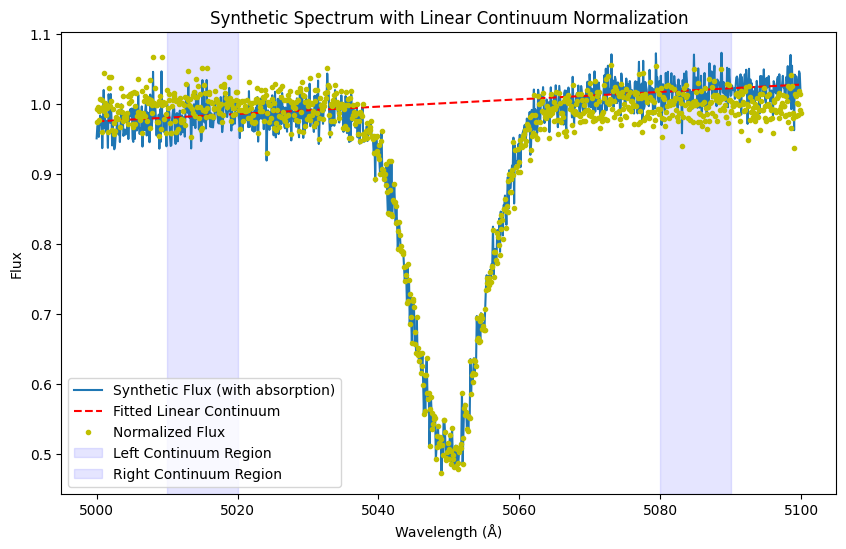

In [411]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.modeling import models, fitting

# Step 1: Create synthetic data
# Wavelength array (e.g., in Angstroms)
wl = np.linspace(5000, 5100, 1000)

# Synthetic continuum: slight linear slope
continuum_true = 1.0 + 0.0005 * (wl - 5050)  # Base flux ~1, small slope

# Add a Gaussian absorption line in the middle (e.g., at 5050 Å)
absorption = models.Gaussian1D(amplitude=-0.5, mean=5050, stddev=5)
f = continuum_true + absorption(wl)  # Flux = continuum + absorption

# Add some noise for realism
noise = np.random.normal(0, 0.02, len(wl))
f += noise

# Step 2: Define line-free continuum regions (in wavelength units)
# Adjust these based on your real data's absorption positions
left_region = (wl > 5010) & (wl < 5020)  # Left side, line-free
right_region = (wl > 5080) & (wl < 5090)  # Right side, line-free

# Mask for fitting the continuum (only line-free regions)
cont_mask = left_region | right_region

# Step 3: Fit a linear model to the continuum points
lin_model = models.Linear1D()
fitter = fitting.LinearLSQFitter()
continuum_fit = fitter(lin_model, wl[cont_mask], f[cont_mask])

# Evaluate the fitted line over the full region
continuum = continuum_fit(wl)

# Normalize the flux
normalized_flux = f / continuum

# Step 4: Plot to visualize (optional, for checking)
plt.figure(figsize=(10, 6))
plt.plot(wl, f, label='Synthetic Flux (with absorption)')
plt.plot(wl, continuum, 'r--', label='Fitted Linear Continuum')
plt.plot(wl, normalized_flux, 'y.', label='Normalized Flux')
plt.axvspan(5010, 5020, color='blue', alpha=0.1, label='Left Continuum Region')
plt.axvspan(5080, 5090, color='blue', alpha=0.1, label='Right Continuum Region')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.legend()
plt.title('Synthetic Spectrum with Linear Continuum Normalization')
plt.show()

## maybe want to incorporate anchor point continuum fitting in astro voigt ?

In [412]:

'''
Alternate style of plotting
'''

# # Create a figure with the overall size (10, 8)
# fig = plt.figure(figsize=(10, 6))

# # Create a GridSpec with 2 rows and 1 column, with different height ratios
# grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# # Add the first subplot (upper image), which will take up 6/8 of the height
# ax1 = fig.add_subplot(grid[0, 0])
# ax1.set_title('Best-fit composite model overlaid on data')
# ax1.plot(wave, flux, 'k.', label='Data')  
# ax1.plot(wave, continuum * AbsorptionLine, 'b-', label='Best-fit model')
# # ax1.plot(wave, continuum * model_comp_0, '-.')
# # ax1.plot(wave, continuum * model_comp_1, '-.')
# for j in clouds_13CHp:
#     ax1.plot(wave, continuum * j, '--')
# for k in clouds_12CHp:
#     ax1.plot(wave, continuum * k, '-.')

# ax1.plot(wave, continuum, 'orange', linewidth=0.5, label='Continuum fit')
# ax1.set_ylabel('Normalized Flux')
# ax1.grid('on', which='both', linestyle='--', linewidth=0.5)
# ax1.legend()

# # Add the second subplot (lower image), which will take up 2/8 of the height
# ax2 = fig.add_subplot(grid[1, 0])
# # ax2.set_title('Residuals after fitting')
# ax2.plot(wave, flux - (continuum * AbsorptionLine), 'k.')  
# ax2.hlines(0, wave.min(), wave.max(), colors='purple', linestyles='dashed')
# # ax2.hlines(rms_error, wave.min(), wave.max(), colors='red', linestyles='dashed')
# # ax2.hlines(-rms_error, wave.min(), wave.max(), colors='red', linestyles='dashed')
# ax2.set_ylabel('Residuals')
# ax2.set_xlabel('Wavelength ($\AA$)')
# ax2.grid('on', which='both', linestyle='--', linewidth=0.5)
# ax2.fill_between(wave, -rms_error, rms_error, color='pink', alpha=0.4, label='$\pm \sigma_{rms}$')
# ax2.legend()
# # Show the plot
# plt.tight_layout()
# plt.show()



'\nAlternate style of plotting\n'

In [413]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Create a figure with the overall size (10, 8)
# fig = plt.figure(figsize=(10, 6))

# # Create a GridSpec with 2 rows and 1 column, with different height ratios
# grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[6, 2])

# # Add the first subplot (upper image), which will take up 6/8 of the height
# ax1 = fig.add_subplot(grid[0, 0])
# ax1.set_title('Best-fit composite model overlaid on data')

# # Plot data and main model
# ax1.plot(wave, flux, 'k.', label='Data', markersize=3)
# ax1.plot(wave, continuum * AbsorptionLine, 'r-', label='Best-fit model', linewidth=2)
# ax1.plot(wave, continuum, 'green', label='Continuum fit', linewidth=2)

# # Define color cycles for different cloud components
# # Using matplotlib's tab20c colormap for distinct colors
# cmap = plt.cm.tab20c
# colors_13CHp = [cmap(i) for i in np.linspace(0, 0.5, len(clouds_13CHp))]
# colors_12CHp = [cmap(i) for i in np.linspace(0.5, 1, len(clouds_12CHp))]

# # Plot 13CH+ clouds with distinct colors
# for idx, j in enumerate(clouds_13CHp):
#     color = colors_13CHp[idx]
#     ax1.plot(wave, continuum * j, '-.', 
#              color=color, 
#              alpha=0.7, 
#              linewidth=1.5,
#              label=f'13CH+ Cloud {idx+1}')

# # Plot 12CH+ clouds with distinct colors
# for idx, k in enumerate(clouds_12CHp):
#     color = colors_12CHp[idx]
#     ax1.plot(wave, continuum * k, '-.', 
#              color=color, 
#              alpha=0.7, 
#              linewidth=1.5,
#              label=f'12CH+ Cloud {idx+1}')

# ax1.set_ylabel('Normalized Flux')
# ax1.grid('on', which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# # Adjust legend to avoid overcrowding
# # You can use ncol parameter to create multiple columns if you have many clouds
# n_clouds = len(clouds_13CHp) + len(clouds_12CHp)
# if n_clouds > 5:
#     ax1.legend(loc='upper right', ncol=2, fontsize='small')
# else:
#     ax1.legend(loc='best')

# # Add the second subplot (lower image), which will take up 2/8 of the height
# ax2 = fig.add_subplot(grid[1, 0])
# ax2.plot(wave, flux - (continuum * AbsorptionLine), 'k.', markersize=3)
# ax2.hlines(0, wave.min(), wave.max(), colors='purple', linestyles='dashed', linewidth=1.5)
# ax2.set_ylabel('Residuals')
# ax2.set_xlabel('Wavelength ($\AA$)')
# ax2.grid('on', which='both', linestyle='--', linewidth=0.5, alpha=0.7)
# ax2.fill_between(wave, -rms_error, rms_error, color='pink', alpha=0.4, label='$\pm \sigma_{rms}$')
# ax2.legend(loc='best')


# # Adjust layout
# plt.tight_layout()

# # Show the plot
# plt.show()